<a href="https://colab.research.google.com/github/Royst97/DSRP_Roy/blob/main/DSRP_2026_Royston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Stuff:

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, permutation_test_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("/content/lendingclub_loans_export.csv")

Exploring the Data:

In [4]:
print(df.dtypes, "\n")
print(df.info())

emp_title                            object
emp_length                          float64
state                                object
homeownership                        object
annual_income                       float64
verified_income                      object
debt_to_income                      float64
annual_income_joint                 float64
verification_income_joint            object
debt_to_income_joint                float64
delinq_2y                             int64
months_since_last_delinq            float64
earliest_credit_line                  int64
inquiries_last_12m                    int64
total_credit_lines                    int64
open_credit_lines                     int64
total_credit_limit                    int64
total_credit_utilized                 int64
num_collections_last_12m              int64
num_historical_failed_to_pay          int64
months_since_90d_late               float64
current_accounts_delinq               int64
total_collection_amount_ever    

In [5]:
print(df.shape, "\n")
print(df.columns)

(10000, 55) 

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'publi

Cleaning the Data:

In [6]:
#Change NA values to null
df = df.replace("NA", np.nan)

#All loans were 2018, remove year from issue month
df["issue_month"] = pd.to_datetime(df["issue_month"], format="%b-%Y").dt.strftime

#Grade information included in subgrade
df.drop(columns = ["grade"], inplace = True)

#Dropping columns with excessive null values and do not pertain to my research
df = df.drop(columns=["annual_income_joint","verification_income_joint","debt_to_income_joint","months_since_last_delinq","months_since_90d_late"])

#Makes a new column to help easier classify whether or not a loaner has had a delinquency
df["had_delinquency"] = df["delinq_2y"] > 0

#Dropping some rows with null values
df = df.dropna(subset=["debt_to_income"])



In [7]:
#Checking for duplicates
print(df.duplicated().sum(), "\n")

print(df.info())

0 

<class 'pandas.core.frame.DataFrame'>
Index: 9976 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9166 non-null   object 
 1   emp_length                        9182 non-null   float64
 2   state                             9976 non-null   object 
 3   homeownership                     9976 non-null   object 
 4   annual_income                     9976 non-null   float64
 5   verified_income                   9976 non-null   object 
 6   debt_to_income                    9976 non-null   float64
 7   delinq_2y                         9976 non-null   int64  
 8   earliest_credit_line              9976 non-null   int64  
 9   inquiries_last_12m                9976 non-null   int64  
 10  total_credit_lines                9976 non-null   int64  
 11  open_credit_lines                 9976 non-null   int64  
 12  total_c

Visuals

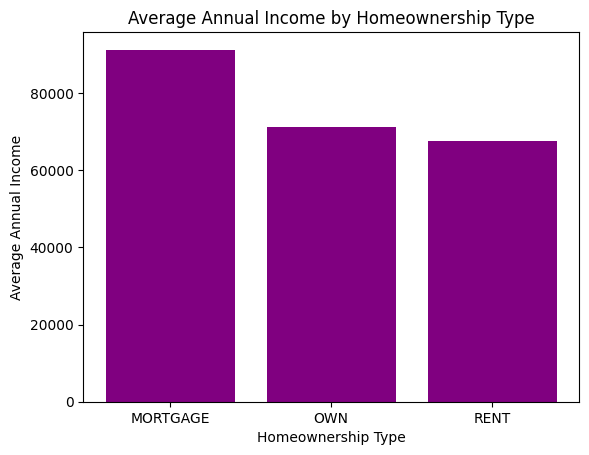

In [8]:
#I might want to do a question based on house ownership compared to something else so this visual is in preparation


avg_anninc = df.groupby("homeownership")["annual_income"].mean()

plt.bar(avg_anninc.index, avg_anninc.values, color="purple")
plt.title("Average Annual Income by Homeownership Type")
plt.xlabel("Homeownership Type")
plt.ylabel("Average Annual Income")

plt.show()

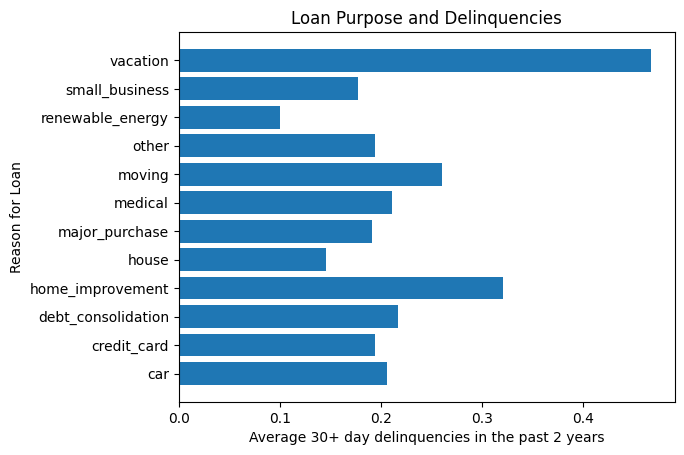

In [9]:
avg_delinq = df.groupby("loan_purpose")["delinq_2y"].mean()

plt.barh(avg_delinq.index, avg_delinq.values)
plt.title("Loan Purpose and Delinquencies")
plt.xlabel("Average 30+ day delinquencies in the past 2 years")
plt.ylabel("Reason for Loan")

plt.show()

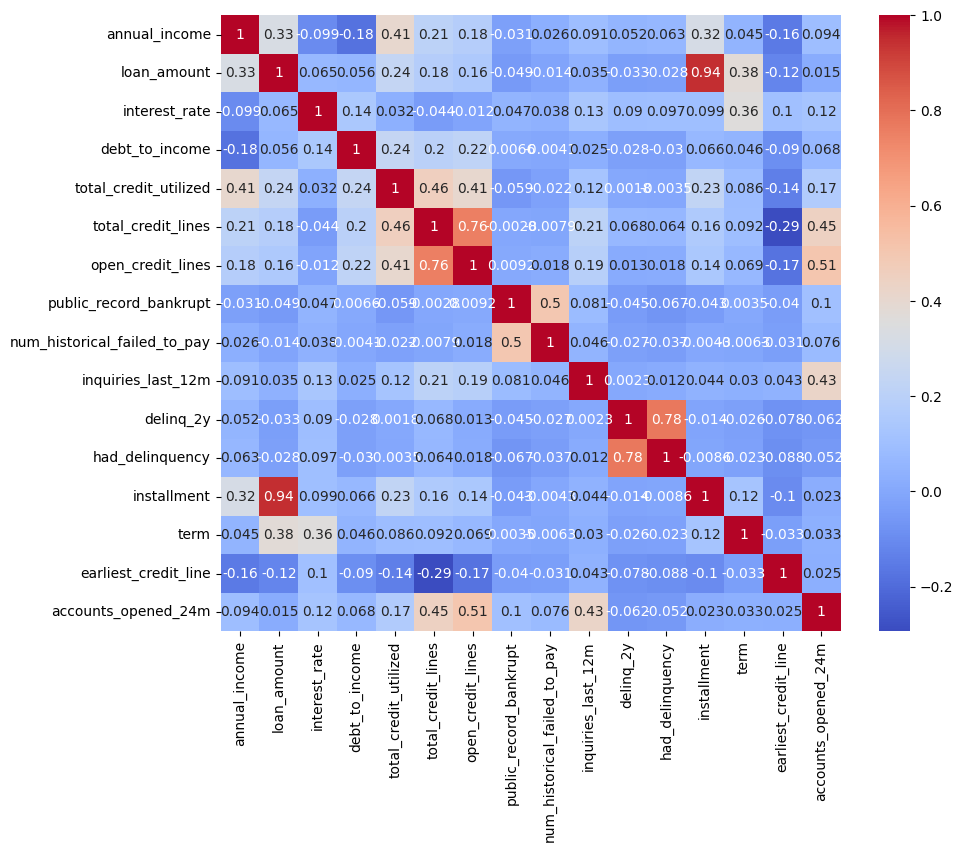

In [10]:
corr = df[
    [
        "annual_income",
        "loan_amount",
        "interest_rate",
        "debt_to_income",
        "total_credit_utilized",
        "total_credit_lines",
        "open_credit_lines",
        "public_record_bankrupt",
        "num_historical_failed_to_pay",
        "inquiries_last_12m",
        "delinq_2y",
        "had_delinquency",
        "installment",
        "term",
        "earliest_credit_line",
        "accounts_opened_24m"
    ]
].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Making the Machine Learning Models

In [11]:
#making dependant and independant variables
x = df[["annual_income",
               "loan_amount",
               "interest_rate",
               "debt_to_income",
               "total_credit_utilized",
               "total_credit_lines",
               "open_credit_lines",
               "public_record_bankrupt",
               "num_historical_failed_to_pay",
               "inquiries_last_12m","tax_liens"]]

y = df["had_delinquency"]

In [12]:
#Splitting the data into training and test parts
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 67, stratify=y)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#Creating the models
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_rf = RandomForestClassifier(class_weight='balanced', random_state = 67)
model_svm = SVC(class_weight='balanced', probability=True)

In [15]:
#Training the models
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [16]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=67)

In [17]:
model_svm.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', probability=True)

In [18]:
pred_lr = model_lr.predict(X_test_scaled)
pred_rf = model_rf.predict(X_test)
pred_svm = model_svm.predict(X_test_scaled)

Looking at Model metrics to determine the best one:

In [19]:
print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))
print("SVM:", accuracy_score(y_test, pred_svm), "\n")

print("Logistic Regression")
print(confusion_matrix(y_test, pred_lr))

print("\nRandom Forest")
print(confusion_matrix(y_test, pred_rf))

print("\nSupport Vector Machine")
print(confusion_matrix(y_test, pred_svm))

Logistic Regression: 0.6232464929859719
Random Forest: 0.8557114228456913
SVM: 0.6067134268537074 

Logistic Regression
[[1082  630]
 [ 122  162]]

Random Forest
[[1706    6]
 [ 282    2]]

Support Vector Machine
[[1059  653]
 [ 132  152]]


Recall and AUC Evaluation:

In [20]:
#Using recall to evaluate the models in finding delinquent borrowers
score_lr, permutation_scores, p_value_lr = permutation_test_score(model_lr,X_train_scaled,y_train,scoring="recall",cv=5,n_permutations=100,random_state=67)

print("Logistic Regression Recall Score:", score_lr)
print("Pvalue:", p_value_lr)


Logistic Regression Recall Score: 0.6003902929128989
Pvalue: 0.019801980198019802


In [28]:
score_rf, permutation_scores, p_value_rf = permutation_test_score(model_rf,X_train,y_train,scoring="recall",cv=5,n_permutations=5,random_state=67)
score_svm, permutation_scores, p_value_svm = permutation_test_score(model_svm,X_train_scaled,y_train,scoring="recall",cv=5,n_permutations=5,random_state=67)

print("\nRandom Forest Recall Score:", score_rf)
print("Pvalue:", p_value_rf)
print("\nSupport Vector Machine Recall Score:", score_svm)
print("Pvalue:", p_value_svm)



Random Forest Recall Score: 0.014081459154494163
Pvalue: 0.16666666666666666

Support Vector Machine Recall Score: 0.5907179843882835
Pvalue: 0.16666666666666666


In [57]:
#Using ROC AUC to evaluate the models in seperating delinquent and non delinquent borrowers
prob_lr = model_lr.predict_proba(X_test_scaled)[:,1]
auc_lr = roc_auc_score(y_test, prob_lr)

prob_rf = model_rf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, prob_rf)

prob_svm = model_svm.predict_proba(X_test_scaled)[:,1]
auc_svm = roc_auc_score(y_test, prob_svm)

print("Logistic Regression AUROC:", auc_lr)
print("Random Forest AUROC:", auc_rf)
print("Support Vector Machine AUROC:", auc_svm)

Logistic Regression AUROC: 0.6387821673028827
Random Forest AUROC: 0.6080648611293933
Support Vector Machine AUROC: 0.6341627451625642


In [34]:
#Getting the roc curve, false positive rate, and true positive rate so I can plot it
fpr_lr, tpr_lr, t_lr = roc_curve(y_test, prob_lr)
fpr_rf, tpr_rf, t_rf = roc_curve(y_test, prob_rf)
fpr_svm, tpr_svm, t_svm = roc_curve(y_test, prob_svm)

In [24]:
#Making a classification report for all of them
print("Logistic Regression")
print(classification_report(y_test, pred_lr))
print("\nRandom Forest")
print(classification_report(y_test, pred_rf))
print("\nSupport Vector Machine")
print(classification_report(y_test, pred_svm))

Logistic Regression
              precision    recall  f1-score   support

       False       0.90      0.63      0.74      1712
        True       0.20      0.57      0.30       284

    accuracy                           0.62      1996
   macro avg       0.55      0.60      0.52      1996
weighted avg       0.80      0.62      0.68      1996


Random Forest
              precision    recall  f1-score   support

       False       0.86      1.00      0.92      1712
        True       0.25      0.01      0.01       284

    accuracy                           0.86      1996
   macro avg       0.55      0.50      0.47      1996
weighted avg       0.77      0.86      0.79      1996


Support Vector Machine
              precision    recall  f1-score   support

       False       0.89      0.62      0.73      1712
        True       0.19      0.54      0.28       284

    accuracy                           0.61      1996
   macro avg       0.54      0.58      0.50      1996
weighted avg   

In [45]:
#Getting my False and True recall values on my models so I can graph them
lr_false = recall_score(y_test,pred_lr, pos_label = False)
lr_true = recall_score(y_test,pred_lr)

rf_false = recall_score(y_test,pred_rf, pos_label = False)
rf_true = recall_score(y_test,pred_rf)

svm_false = recall_score(y_test,pred_svm, pos_label = False)
svm_true = recall_score(y_test,pred_svm)

Final Visualizations:

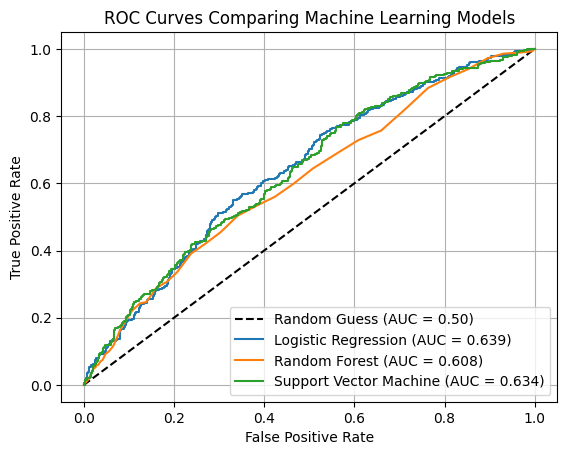

In [43]:
#this first graph visualizes my AUROC results
#Plotting the actual ROC curve
plt.plot([0,1], [0,1], linestyle="--", color="black", label= "Random Guess (AUC = 0.50)")
plt.plot(fpr_lr, tpr_lr, label= f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf,  label= f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_svm, tpr_svm, label= f"Support Vector Machine (AUC = {auc_svm:.3f})")

#TITLE
plt.title("ROC Curves Comparing Machine Learning Models")
#labeling my axes
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")


#actual visuals
plt.legend()
plt.grid()
plt.show()

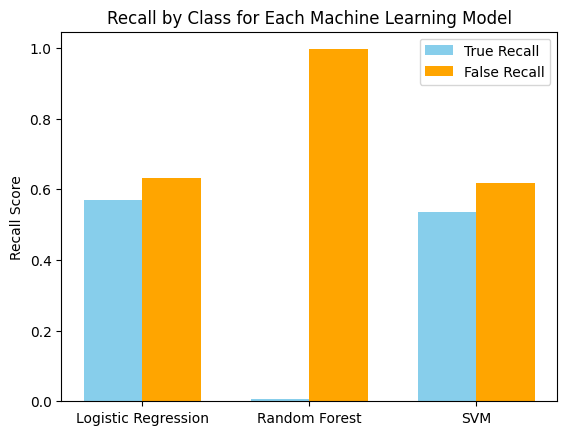

In [56]:
# Creating a double bar graph to visualize my false and true recall scores
#x axis labels
models = ["Logistic Regression", "Random Forest", "SVM"]

#y axis data
false_recall = [lr_false, rf_false, svm_false]
true_recall = [lr_true, rf_true, svm_true]

#plotting it
x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, true_recall, width, label= "True Recall", color = "skyblue")
plt.bar(x + width/2, false_recall, width, label= "False Recall",  color = "orange")

#axis labels boundaries and such
plt.xticks(x, models)
plt.ylabel("Recall Score")


#title and a tad bit of beautifying???
plt.title("Recall by Class for Each Machine Learning Model")
plt.legend()

plt.show()